In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pickle
import torch
from torch_geometric.data import Data
print(os.getpid())

119961


In [2]:
def sinusoidal_positional_encoding(N, d_model):
    pe = torch.zeros(N, d_model)
    position = torch.arange(0, N, dtype=torch.float).unsqueeze(1)
    div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-torch.log(torch.tensor(10000.0)) / d_model))
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    return pe  # shape [N, d_model]

In [3]:
def build_graph(filename, sequence, score_map, distance_map=None, sep_min=0):
    
    N = len(sequence)

    # score map to tensor
    score_map = torch.tensor(score_map, dtype=torch.float)
    #score_map = torch.log(score_map + 1.0)  #renormalization to see again when we have more data
    #score_map = (score_map - score_map.mean()) / (score_map.std() + 1e-6)
    idx = torch.arange(N)
    i, j = torch.meshgrid(idx, idx, indexing='ij')  # shape [N, N]

    sep = torch.abs(i - j).float()
    sep_bucket = torch.clamp(sep, max=32).long()


    # masks
    not_self = i != j
    pair_mask = i < j
    long_range_ok = (torch.abs(i - j) >= sep_min)

    if distance_map is not None:
        distance_map = torch.tensor(distance_map, dtype=torch.float)
        distance_map=torch.log((distance_map)/8) #renormalization to see again when we have more data
        known = torch.isfinite(distance_map)
        labels = distance_map
    else:
        known = torch.ones((N, N), dtype=torch.bool)
        labels = torch.zeros((N, N), dtype=torch.float)

    edge_mask = known & long_range_ok

    # remove i == j
    valid = not_self

    src = i[valid]
    dst = j[valid]

    # after you create src, dst for all i != j
    edge_to_idx = {(int(s), int(d)): k for k, (s, d) in enumerate(zip(src.tolist(), dst.tolist()))}
    rev_edge_idx = torch.tensor([edge_to_idx[(int(d), int(s))] for s, d in zip(src.tolist(), dst.tolist())],dtype=torch.long)

    edge_index = torch.stack([src, dst], dim=0)

    #edge_attr = score_map[valid].unsqueeze(-1)
    y = labels[valid].unsqueeze(-1)

    mask = edge_mask[valid]
    pair_mask = pair_mask[valid]

    x = sinusoidal_positional_encoding(N, d_model=16)

    return Data(
        x=x,
        edge_index=edge_index,
        #edge_attr=edge_attr,
        edge_attr = torch.stack([score_map[valid],sep_bucket[valid].float()], dim=-1),
        y=y,
        edge_mask=mask,
        pair_mask=pair_mask,
        rev_edge_idx=rev_edge_idx,
        L=N,
        filename=filename
    )

In [4]:
folder_path = "Data_C_alpha"

all_data = []
for file in os.listdir(folder_path):
    if file.endswith(".pkl"):    #and (file== "data_PF00014.pkl" or file== "data_PF01640.pkl")
        full_path = os.path.join(folder_path, file)
        
        with open(full_path, "rb") as f:
            loaded = pickle.load(f)

        filename=str(file)
        sequence=loaded['sequence']
        distance_map=loaded['distance_map']
        contact_map_DCA=loaded['dca']
        data = build_graph(filename,sequence, contact_map_DCA, distance_map)
        all_data.append(data)


from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split

# train_loader=DataLoader(all_data, batch_size=1, shuffle=True) 
# test_loader=DataLoader(all_data, batch_size=1, shuffle=True) 

train_data, test_data = train_test_split(all_data, test_size=0.2, random_state=0)


train_loader = DataLoader(train_data, batch_size=1, shuffle=True) 
test_loader = DataLoader(test_data, batch_size=1, shuffle=False)

In [5]:
import numpy as np
from Bio.PDB import PDBParser, Polypeptide
from scipy.spatial.distance import pdist, squareform
from scipy.optimize import minimize

def classical_mds(D, n_components=3):
    """
    Classical MDS for a complete distance matrix.
    """
    D = np.asarray(D, dtype=float)
    n = D.shape[0]

    D2 = D ** 2
    J = np.eye(n) - np.ones((n, n)) / n
    B = -0.5 * J @ D2 @ J

    evals, evecs = np.linalg.eigh(B)
    idx = np.argsort(evals)[::-1]
    evals = evals[idx]
    evecs = evecs[:, idx]

    vals = np.maximum(evals[:n_components], 0.0)
    X = evecs[:, :n_components] * np.sqrt(vals)
    return X


def get_valid_mask(dm, mi, min_finite_per_row=1):
    dm = np.asarray(dm, dtype=float)
    mi = np.asarray(mi, dtype=int)

    # residue exists in the mapped structure
    ###problema2
    mapped = mi >= 0

    # residue has enough finite distances to be useful
    enough_contacts = np.isfinite(dm).sum(axis=1) >= min_finite_per_row

    return mapped & enough_contacts

def get_filtered_residues_like_mapPDBToHMM(pdbFile, chainIds):
    """
    Rebuilds the residue list in the same spirit/order as mapPDBToHMM.
    Assumes chainIds is a string like 'A' or 'AB'.
    """
    chainIds = list(chainIds)
    structure = PDBParser(QUIET=True).get_structure('void', pdbFile)

    chains = structure[0].get_chains()
    residues = [chain.get_list() for chain in chains if chain.id in chainIds]
    residues = [res for resList in residues for res in resList]

    filtered_residues = []
    filtered_seq = []

    for res in residues:
        if Polypeptide.is_aa(res, standard=True):
            try:
                aa = Polypeptide.protein_letters_3to1[res.get_resname()]
            except Exception:
                continue
            filtered_residues.append(res)
            filtered_seq.append(aa)

    if len(filtered_residues) == 0:
        raise ValueError(f"No standard amino-acid residues found on chains {chainIds}")

    return filtered_residues, ''.join(filtered_seq)


def residue_rep_coord(res, distType='all'):
    """
    distType:
      - 'all'   -> centroid of all atoms in the residue
      - 'alpha' -> CA
      - 'beta'  -> CB, or CA for GLY
    """
    if distType == 'alpha':
        if "CA" in res:
            return res["CA"].get_coord()
        # fallback
        atoms = [a.get_coord() for a in res.get_atoms()]
        return np.mean(atoms, axis=0) if atoms else np.array([np.nan, np.nan, np.nan])

    if distType == 'beta':
        if res.get_resname() == 'GLY':
            if "CA" in res:
                return res["CA"].get_coord()
        else:
            if "CB" in res:
                return res["CB"].get_coord()
        # fallback
        if "CA" in res:
            return res["CA"].get_coord()
        atoms = [a.get_coord() for a in res.get_atoms()]
        return np.mean(atoms, axis=0) if atoms else np.array([np.nan, np.nan, np.nan])

    # distType == 'all'
    atoms = [a.get_coord() for a in res.get_atoms()]
    return np.mean(atoms, axis=0) if atoms else np.array([np.nan, np.nan, np.nan])


def graph_to_matrix(data, values, mask=None):
    num_nodes = data.x.shape[0]
    mat = torch.zeros((num_nodes, num_nodes))

    edge_index = data.edge_index

    if mask is not None:
        edge_index = edge_index[:, mask]
        values = values[mask]
    mat[edge_index[0], edge_index[1]] = values.squeeze()

    return mat

In [ ]:
from sequenceHandler import mapPDBToHMM
from torch_geometric.data import Data
import numpy as np
import torch
import os


all_new_data = []

for data in all_data:

    # ---------------------------------------------------------
    # Original data
    # ---------------------------------------------------------

    mask = data.edge_mask

    true_dist_map = graph_to_matrix(
        data,
        data.y,
        mask
    )

    true_dm = 8 * np.exp(
        np.asanyarray(true_dist_map)
    )

    true_dm = np.asarray(
        true_dm,
        dtype=float
    )

    # ---------------------------------------------------------
    # Get filename / Pfam ID
    # ---------------------------------------------------------

    # Here data is a single Data object, so usually filename
    # is already a string.
    filename = str(data.filename)

    pfam_id = (
        filename
        .removeprefix("data_")
        .removesuffix(".pkl")
    )

    pdb_file = f"PDB/{pfam_id}.pdb"
    chain_id = "A"
    hmm_file = f"HMM/{pfam_id}.hmm"

    hmm_file_2 = "None"
    output_map_file = "None"

    # ---------------------------------------------------------
    # Map PDB residues to HMM
    # ---------------------------------------------------------

    _, mi, aligned_sequence = mapPDBToHMM(
        pdb_file,
        chain_id,
        hmm_file,
        hmm_file_2,
        output_map_file,
        distType="alpha"
    )

    mi = np.asarray(mi, dtype=int)

    # ---------------------------------------------------------
    # Select valid residues
    # ---------------------------------------------------------

    valid = get_valid_mask(
        true_dm,
        mi,
        min_finite_per_row=1
    )

    if valid.sum() < 4:
        raise ValueError(
            f"{pfam_id}: too few valid residues "
            f"({valid.sum()})"
        )

    D = true_dm[np.ix_(valid, valid)]

    if np.isinf(D).any() or np.isnan(D).any():
        raise ValueError(
            f"{pfam_id}: D contains inf/nan after filtering."
        )

    # Symmetrize
    D = 0.5 * (D + D.T)
    np.fill_diagonal(D, 0.0)

    # ---------------------------------------------------------
    # MDS
    # ---------------------------------------------------------

    X0 = classical_mds(
        D,
        n_components=3
    )

    # ---------------------------------------------------------
    # Reference PDB coordinates
    # ---------------------------------------------------------

    residues, seq = get_filtered_residues_like_mapPDBToHMM(
        pdb_file,
        chain_id
    )

    rep_coords = np.asarray(
        [
            residue_rep_coord(
                res,
                distType="alpha"
            )
            for res in residues
        ],
        dtype=float
    )

    coords_full = np.full(
        (len(mi), 3),
        np.nan,
        dtype=float
    )

    #problema 1
    idx = mi[valid]

    if np.any(idx < 0) or np.any(idx >= len(rep_coords)):
        raise ValueError(
        f"Invalid PDB indices: {idx.min()} ... {idx.max()}, "
        f"number of residues: {len(rep_coords)}"
    )

    coords_full[valid] = rep_coords[idx]

    X_ref = coords_full[valid]

###############
    # from scipy.spatial.distance import cdist

    # D_ref = cdist(
    #     X_ref,
    #     X_ref
    # )

    # print("Difference between MDS D and PDB D:")
    # print(
    #     np.sqrt(
    #         np.mean(
    #             (D - D_ref) ** 2
    #         )
    #     )
    # )

    # print("mi:", mi[valid][:20])
    # print("PDB indices:", idx[:20])
    # print("First PDB coordinates:")
    # print(rep_coords[idx[:5]])

    # print("First X_ref:")
    # print(X_ref[:5])
################
    # ---------------------------------------------------------
    # Convert valid mask to torch
    # ---------------------------------------------------------

    valid_t = torch.as_tensor(
        valid,
        dtype=torch.bool,
        device=data.x.device
    )

    # ---------------------------------------------------------
    # Filter node features
    # ---------------------------------------------------------

    x_new = data.x[valid_t]

    # ---------------------------------------------------------
    # Filter edges
    # ---------------------------------------------------------

    src = data.edge_index[0]
    dst = data.edge_index[1]

    edge_keep = (
        valid_t[src]
        & valid_t[dst]
    )

    # Map old node indices -> new node indices
    old_to_new = torch.full(
        (data.x.shape[0],),
        -1,
        dtype=torch.long,
        device=data.x.device
    )

    old_to_new[valid_t] = torch.arange(
        valid_t.sum(),
        device=data.x.device
    )

    edge_index_new = torch.stack(
        [
            old_to_new[src[edge_keep]],
            old_to_new[dst[edge_keep]]
        ],
        dim=0
    )

    edge_attr_new = data.edge_attr[edge_keep]

    # ---------------------------------------------------------
    # Filter edge mask
    # ---------------------------------------------------------

    if data.edge_mask.dim() == 2:

        edge_mask_new = (
            data.edge_mask[valid_t][:, valid_t]
        )

    else:

        edge_mask_new = data.edge_mask[edge_keep]

    # ---------------------------------------------------------
    # Convert coordinates to torch
    # ---------------------------------------------------------

    X0 = torch.as_tensor(
        X0,
        dtype=torch.float32
    )

    X_ref = torch.as_tensor(
        X_ref,
        dtype=torch.float32
    )

    # ---------------------------------------------------------
    # Build new Data object
    # ---------------------------------------------------------

    new_data = Data(
        x=x_new.cpu(),
        edge_index=edge_index_new.cpu(),
        edge_attr=edge_attr_new.cpu(),

        # MDS coordinates = EGNN input
        pos=X0,

        # Real PDB coordinates = target
        y=X_ref,

        edge_mask=edge_mask_new.cpu(),

        filename=filename,
        L=data.L
    )

    all_new_data.append(new_data)


    


/home/fabio/miniconda3/envs/Internship/lib/python3.14/site-packages/Bio/PDB/Atom.py:237: PDBConstructionWarning: Used element 'U' for Atom (name=UNK) with given element 'X'
  warnings.warn(msg, PDBConstructionWarning)
/home/fabio/miniconda3/envs/Internship/lib/python3.14/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain A is discontinuous at line 1232.
  warnings.warn(
/home/fabio/miniconda3/envs/Internship/lib/python3.14/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain B is discontinuous at line 1285.
  warnings.warn(
/home/fabio/miniconda3/envs/Internship/lib/python3.14/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain A is discontinuous at line 4943.
  warnings.warn(
/home/fabio/miniconda3/envs/Internship/lib/python3.14/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain B is discontinuous at line 4986.
  warnings.warn(
/home/fabio/miniconda3

In [32]:

torch.save(all_new_data, "all_new_data_prova.pt") 
all_New_data = torch.load("all_new_data_prova.pt",weights_only=False)  

In [8]:
print(len(all_new_data))

1560


In [9]:
from sklearn.model_selection import train_test_split
from torch_geometric.loader import DataLoader

train_data, test_data = train_test_split(
    all_new_data,
    test_size=0.2,
    random_state=0
)

train_loader = DataLoader(
    train_data,
    batch_size=1,
    shuffle=True
)

test_loader = DataLoader(
    test_data,
    batch_size=1,
    shuffle=False
)

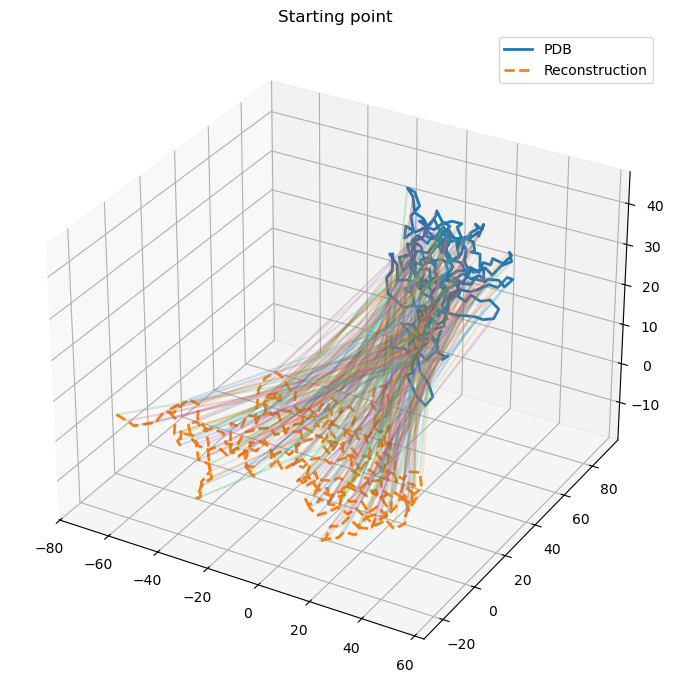

In [10]:
def plot_3d_overlay(X_ref, X_rec_aligned, title="3D comparison"):
    """
    X_ref: reference coordinates (from PDB, centered)
    X_rec_aligned: reconstructed coordinates aligned to reference
    """

    fig = plt.figure(figsize=(8, 7))
    ax = fig.add_subplot(111, projection='3d')

    # Plot PDB reference
    ax.plot(
        X_ref[:, 0], X_ref[:, 1], X_ref[:, 2],
        label="PDB",
        linewidth=2
    )

    # Plot reconstructed
    ax.plot(
        X_rec_aligned[:, 0], X_rec_aligned[:, 1], X_rec_aligned[:, 2],
        linestyle='--',
        label="Reconstruction",
        linewidth=2
    )

    # Optionally connect corresponding residues (helps visually)
    for i in range(len(X_ref)):
        ax.plot(
            [X_ref[i, 0], X_rec_aligned[i, 0]],
            [X_ref[i, 1], X_rec_aligned[i, 1]],
            [X_ref[i, 2], X_rec_aligned[i, 2]],
            alpha=0.2
        )

    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()


plot_3d_overlay(
    X_ref,
    X0, 
    title=f"Starting point"
)





In [11]:
data = next(iter(train_loader))

print(data)
print("pos:", data.pos.shape)
print("y:", data.y.shape)
print("x:", data.x.shape)
print("edge_index:", data.edge_index.shape)
print("edge_attr:", data.edge_attr.shape)

DataBatch(x=[127, 16], edge_index=[2, 16002], edge_attr=[16002, 2], y=[127, 3], pos=[127, 3], edge_mask=[16002], filename=[1], L=[1], batch=[127], ptr=[2])
pos: torch.Size([127, 3])
y: torch.Size([127, 3])
x: torch.Size([127, 16])
edge_index: torch.Size([2, 16002])
edge_attr: torch.Size([16002, 2])


In [12]:
import torch
import torch.nn as nn
from torch_geometric.utils import scatter


class MLP(nn.Module):
    def __init__(
        self,
        in_dim,
        hidden_dim,
        out_dim,
        dropout=0.0,
    ):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, out_dim),
        )

    def forward(self, x):
        return self.net(x)


class EGNNLayer(nn.Module):
    """
    One E(3)/E(n)-equivariant message passing layer.

    Inputs
    ------
    h:
        [N, hidden_dim]
        scalar node features

    x:
        [N, 3]
        node coordinates

    edge_index:
        [2, E]

    edge_attr:
        [E, edge_dim]

    Returns
    -------
    h_new:
        [N, hidden_dim]

    x_new:
        [N, 3]
    """

    def __init__(
        self,
        hidden_dim,
        edge_dim,
        dropout=0.0,
        coord_scale=0.1,
    ):
        super().__init__()

        self.coord_scale = coord_scale

        # Message:
        #
        # h_i, h_j, edge_attr_ij, ||x_i-x_j||^2
        #
        self.edge_mlp = MLP(
            in_dim=2 * hidden_dim + edge_dim + 1,
            hidden_dim=hidden_dim,
            out_dim=hidden_dim,
            dropout=dropout,
        )

        # Node update
        self.node_mlp = MLP(
            in_dim=2 * hidden_dim,
            hidden_dim=hidden_dim,
            out_dim=hidden_dim,
            dropout=dropout,
        )

        # Scalar multiplying the relative coordinate.
        #
        # tanh keeps this update bounded.
        #
        self.coord_mlp = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1),
            nn.Tanh(),
        )

    def forward(
        self,
        h,
        x,
        edge_index,
        edge_attr,
    ):

        row, col = edge_index

        # ---------------------------------------------------------
        # Relative coordinates
        # ---------------------------------------------------------

        rel = x[row] - x[col]              # [E, 3]

        # Squared distance is rotation invariant
        dist2 = (rel ** 2).sum(dim=-1, keepdim=True)  # [E, 1]

        # ---------------------------------------------------------
        # Construct edge messages
        # ---------------------------------------------------------

        m_input = torch.cat(
            [
                h[row],
                h[col],
                edge_attr,
                dist2,
            ],
            dim=-1,
        )

        m = self.edge_mlp(m_input)         # [E, hidden_dim]

        # ---------------------------------------------------------
        # Coordinate update
        # ---------------------------------------------------------

        coord_weight = self.coord_mlp(m)   # [E, 1]

        dx = rel * coord_weight            # [E, 3]

        # Aggregate neighbor coordinate corrections
        dx = scatter(
            dx,
            col,
            dim=0,
            dim_size=x.size(0),
            reduce="mean",
        )

        x_new = x + self.coord_scale * dx

        # ---------------------------------------------------------
        # Node feature update
        # ---------------------------------------------------------

        aggregated_m = scatter(
            m,
            col,
            dim=0,
            dim_size=h.size(0),
            reduce="mean",
        )

        h_update = self.node_mlp(
            torch.cat([h, aggregated_m], dim=-1)
        )

        h_new = h + h_update

        return h_new, x_new

In [13]:
class EGNNRefiner(nn.Module):

    def __init__(
        self,
        node_dim,
        edge_dim,
        hidden_dim=128,
        n_layers=6,
        dropout=0.0,
        coord_scale=0.05,
    ):
        super().__init__()

        self.node_encoder = nn.Sequential(
            nn.Linear(node_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )

        self.layers = nn.ModuleList([
            EGNNLayer(
                hidden_dim=hidden_dim,
                edge_dim=edge_dim,
                dropout=dropout,
                coord_scale=coord_scale,
            )
            for _ in range(n_layers)
        ])

    def forward(
        self,
        x0,
        node_feat,
        edge_index,
        edge_attr,
    ):

        h = self.node_encoder(node_feat)

        x = x0

        for layer in self.layers:
            h, x = layer(
                h,
                x,
                edge_index,
                edge_attr,
            )

        return x

In [14]:
def pairwise_distance_loss(
    pred,
    target,
    eps=1e-8,
):
    """
    pred:   [N, 3]
    target: [N, 3]
    """

    D_pred = torch.cdist(pred, pred)
    D_true = torch.cdist(target, target)

    mask = ~torch.eye(
        pred.shape[0],
        dtype=torch.bool,
        device=pred.device,
    )

    return (
        D_pred[mask] - D_true[mask]
    ).pow(2).mean()

def kabsch_loss(pred, target):
    """
    Rotation + translation invariant coordinate loss.

    pred:
        [N, 3]

    target:
        [N, 3]
    """

    # Remove translation
    pred_c = pred - pred.mean(dim=0, keepdim=True)
    target_c = target - target.mean(dim=0, keepdim=True)

    # Covariance
    H = pred_c.T @ target_c

    # SVD
    U, S, Vh = torch.linalg.svd(H)

    V = Vh.T

    # Proper rotation
    d = torch.det(V @ U.T)

    correction = torch.eye(
        3,
        device=pred.device,
        dtype=pred.dtype,
    )

    correction[-1, -1] = d

    R = V @ correction @ U.T

    pred_aligned = pred_c @ R.T

    return (
        pred_aligned - target_c
    ).pow(2).mean()

In [15]:
save_path="best_model_3d_reconstruction_fake.pt"

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = EGNNRefiner(
    node_dim=all_new_data[0].x.shape[-1],
    edge_dim=all_new_data[0].edge_attr.shape[-1],
    hidden_dim=128,
    n_layers=6,
    coord_scale=0.05,
).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-5
)


scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=5
)


best_val_loss = float("inf")
epochs_no_improve = 0
patience=50
train_losses = []
val_losses = []

for epoch in range(500):

    model.train()

    total_loss = 0.0

    for data in train_loader:

        data = data.to(device)

        optimizer.zero_grad()

        X_pred = model(
            x0=data.pos,
            node_feat=data.x,
            edge_index=data.edge_index,
            edge_attr=data.edge_attr,
        )

        loss_dist = pairwise_distance_loss(
            X_pred,
            data.y
        )

        loss_kabsch = kabsch_loss(
            X_pred,
            data.y
        )

        loss = (
            loss_dist
            + 0.1 * loss_kabsch
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        total_loss += loss.item()

    train_loss = total_loss / len(train_loader)

    model.eval()
    total_loss_val = 0.0
    with torch.no_grad():
    
        for data in test_loader:
        
            data = data.to(device)
    
            optimizer.zero_grad()
    
            X_pred = model(
                x0=data.pos,
                node_feat=data.x,
                edge_index=data.edge_index,
                edge_attr=data.edge_attr,
            )
    
            loss_dist = pairwise_distance_loss(
                X_pred,
                data.y
            )
    
            loss_kabsch = kabsch_loss(
                X_pred,
                data.y
            )
    
            loss = (
                loss_dist
                + 0.1 * loss_kabsch
            )
    
    
            total_loss_val += loss.item()
        
    val_loss = total_loss_val / len(test_loader)


    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0

        torch.save(model.state_dict(), save_path)
    
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= patience:
        print(f"Early stopping triggered after {epoch+1} epochs")
        break



Epoch 0: Train Loss=2.5922, Val Loss=2.4396


KeyboardInterrupt: 

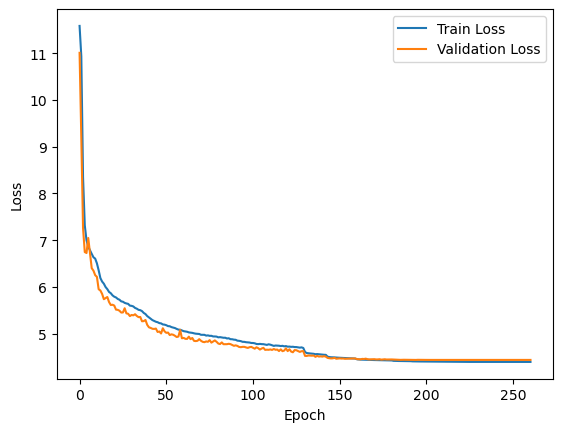

In [16]:
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [16]:
def extract_reference_coords_from_mi(pdbFile, chainIds, mi, distType='all'):
    residues, seq = get_filtered_residues_like_mapPDBToHMM(pdbFile, chainIds)
    rep_coords = np.asarray([residue_rep_coord(res, distType=distType) for res in residues], dtype=float)

    mi = np.asarray(mi, dtype=int)
    coords_full = np.full((len(mi), 3), np.nan, dtype=float)

    valid = mi >= 1
    idx = mi[valid] - 1

    if np.any(idx < 0) or np.any(idx >= len(rep_coords)):
        raise ValueError("mi contains indices outside the filtered residue list.")

    coords_full[valid] = rep_coords[idx]
    return coords_full, residues, seq

def save_coords_as_pdb(coords, filename="reconstructed.pdb", chain_id="A"):
    """
    Save coordinates as a fake CA-only PDB for visualization.
    """
    with open(filename, "w") as f:
        for i, (x, y, z) in enumerate(coords, start=1):
            f.write(
                f"ATOM  {i:5d}  CA  ALA {chain_id}{i:4d}    "
                f"{x:8.3f}{y:8.3f}{z:8.3f}  1.00  0.00           C\n"
            )

                # Write CONECT records (chain connectivity)
        for i in range(1, len(coords)):
            f.write(f"CONECT{i:5d}{i+1:5d}\n")
            f.write(f"CONECT{i+1:5d}{i:5d}\n")
            
        f.write("END\n")


def kabsch_align(P, Q):
    """
    Align P onto Q with optimal rotation after centering.
    Returns aligned P, centered Q, RMSD.
    """
    P = np.asarray(P, dtype=float)
    Q = np.asarray(Q, dtype=float)

    Pc = P - P.mean(axis=0)
    Qc = Q - Q.mean(axis=0)

    C = Pc.T @ Qc
    V, S, Wt = np.linalg.svd(C)
    d = np.sign(np.linalg.det(V @ Wt))
    R = V @ np.diag([1.0, 1.0, d]) @ Wt

    P_aligned = Pc @ R
    rmsd_val = np.sqrt(np.mean(np.sum((P_aligned - Qc) ** 2, axis=1)))
    return P_aligned, Qc, rmsd_val

def best_alignment_with_mirror(P, Q):
    """
    Distance maps cannot distinguish mirror images.
    Try both orientations and keep the better one.
    """
    P1, Qc1, r1 = kabsch_align(P, Q)

    Pm = P.copy()
    Pm[:, 0] *= -1
    P2, Qc2, r2 = kabsch_align(Pm, Q)

    if r2 < r1:
        return P2, Qc2, r2, "mirrored"
    return P1, Qc1, r1, "normal"


#if i want scaling
def optimal_scaling(P, Q):
    """
    Find scalar s minimizing ||sP - Q||^2
    """
    num = np.sum(P * Q)
    den = np.sum(P * P)
    return num / den

def align_with_scaling(P, Q):
    """
    Align P onto Q with rotation + scaling
    """
    # center
    Pc = P - P.mean(axis=0)
    Qc = Q - Q.mean(axis=0)

    # rotation (Kabsch)
    C = Pc.T @ Qc
    V, S, Wt = np.linalg.svd(C)
    d = np.sign(np.linalg.det(V @ Wt))
    R = V @ np.diag([1, 1, d]) @ Wt

    P_rot = Pc @ R

    # scaling
    s = optimal_scaling(P_rot, Qc)
    P_scaled = s * P_rot

    rmsd = np.sqrt(np.mean(np.sum((P_scaled - Qc)**2, axis=1)))

    return P_scaled, Qc, rmsd, s


def best_alignment_with_scaling_and_mirror(P, Q):
    # normal
    P1, Qc1, r1, s1 = align_with_scaling(P, Q)

    # mirrored
    Pm = P.copy()
    Pm[:, 0] *= -1
    P2, Qc2, r2, s2 = align_with_scaling(Pm, Q)

    if r2 < r1:
        return P2, Qc2, r2, s2, "mirrored"
    else:
        return P1, Qc1, r1, s1, "normal"


MDS loss : 4.717300994272478e-10
GNN loss : 5.260988712310791
MDS scale: 0.9999999962371342
GNN scale: 0.9935538332682332
MDS RMSD : 2.9515863392919484e-05
GNN RMSD : 2.3746573464773486


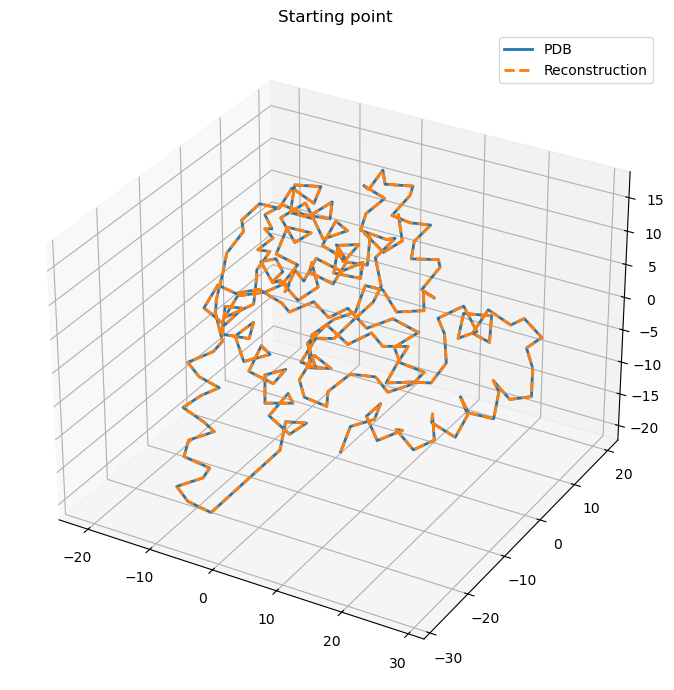

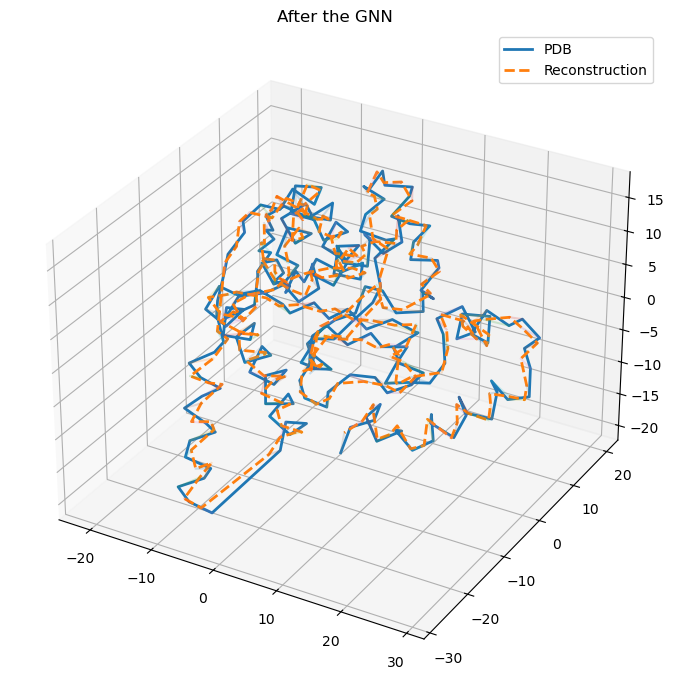

In [30]:
save_path="best_model_3d_reconstruction.pt"
model.load_state_dict(torch.load(save_path))

model.eval()
data = next(iter(train_loader))
data = data.to(device)

with torch.no_grad():
    X_pred = model(
                x0=data.pos,
                node_feat=data.x,
                edge_index=data.edge_index,
                edge_attr=data.edge_attr,
            )

X_mds = data.pos
X_ref = data.y

loss_mds = (
        pairwise_distance_loss(X_mds, X_ref)
        + 0.1 * kabsch_loss(X_mds, X_ref)
    )

loss_gnn = (
        pairwise_distance_loss(X_pred, X_ref)
        + 0.1 * kabsch_loss(X_pred, X_ref)
    )

print("MDS loss :", loss_mds.item())
print("GNN loss :", loss_gnn.item())

X_pred = X_pred.cpu().numpy()
X_mds = X_mds.cpu().numpy()
X_ref = X_ref.cpu().numpy()


X_pred_aligned, X_ref_centered, rmsd_pred, scale_pred, orientation_pred = best_alignment_with_scaling_and_mirror(X_pred, X_ref)
X_mds_aligned, X_ref_centered, rmsd_mds, scale_mds, orientation_mds = best_alignment_with_scaling_and_mirror(X_mds, X_ref)
print("MDS scale:", scale_mds)
print("GNN scale:", scale_pred)




# X_pred_aligned, X_ref_centered, rmsd_pred, orientation_pred = best_alignment_with_mirror(X_pred, X_ref)
# X_mds_aligned, X_ref_centered, rmsd_mds, orientation_mds = best_alignment_with_mirror(X_mds, X_ref)

print("MDS RMSD :", rmsd_mds)
print("GNN RMSD :", rmsd_pred)



plot_3d_overlay(
    X_ref_centered,
    X_mds_aligned, 
    title=f"Starting point"
)

plot_3d_overlay(
    X_ref_centered,
    X_pred_aligned, 
    title=f"After the GNN"
)





save_coords_as_pdb(X_ref_centered, "reference_PDB.pdb")
save_coords_as_pdb(X_mds_aligned, "reconstructed_MDS.pdb")
save_coords_as_pdb(X_pred_aligned, "reconstructed_GNN.pdb")

In [31]:
def test_offsets(P, Q, max_shift=3):
    results = []

    for shift in range(-max_shift, max_shift + 1):

        if shift > 0:
            # P[i] compared with Q[i + shift]
            P_use = P[:-shift]
            Q_use = Q[shift:]

        elif shift < 0:
            # P[i - shift] compared with Q[i]
            k = -shift
            P_use = P[k:]
            Q_use = Q[:-k]

        else:
            P_use = P
            Q_use = Q

        _, _, rmsd, scale, orientation = \
            best_alignment_with_scaling_and_mirror(P_use, Q_use)

        results.append(
            (shift, len(P_use), rmsd, scale, orientation)
        )

    return results

results = test_offsets(X_mds, X_ref, max_shift=3)

for shift, n, rmsd, scale, orientation in results:
    print(
        f"shift={shift:+d}   "
        f"N={n:4d}   "
        f"RMSD={rmsd:.4f}   "
        f"scale={scale:.4f}   "
        f"{orientation}"
    )


print("MDS:", X_mds.shape)
print("REF:", X_ref.shape)
print("mi:", mi[:20])

shift=-3   N= 223   RMSD=7.1260   scale=0.9135   normal
shift=-2   N= 224   RMSD=5.9398   scale=0.9404   normal
shift=-1   N= 225   RMSD=3.9183   scale=0.9738   normal
shift=+0   N= 226   RMSD=0.0000   scale=1.0000   normal
shift=+1   N= 225   RMSD=3.9224   scale=0.9759   normal
shift=+2   N= 224   RMSD=5.9444   scale=0.9418   normal
shift=+3   N= 223   RMSD=7.1293   scale=0.9144   normal
MDS: (226, 3)
REF: (226, 3)
mi: [12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31]


In [19]:
import pandas as pd
ref_mds_error = np.linalg.norm(X_mds_aligned - X_ref_centered, axis=1)
ref_mds_error_shifted = np.linalg.norm(np.vstack([np.zeros((1, 3)),X_mds_aligned[:-1]]) - X_ref_centered, axis=1)
ref_gnn_error = np.linalg.norm(X_pred_aligned - X_ref_centered, axis=1)

df = pd.DataFrame(
    np.hstack([
        X_ref_centered,
        X_mds_aligned,
        X_pred_aligned,
        ref_mds_error[:, None],
        ref_mds_error_shifted[:, None],
        ref_gnn_error[:, None]
    ]),
    columns=[
        "Ref_X", "Ref_Y", "Ref_Z",
        "MDS_X", "MDS_Y", "MDS_Z",
        "GNN_X", "GNN_Y", "GNN_Z", "MDS_Error", "MDS_Error_Shifted", "GNN_Error"
    ]
)

df.index.name = "Residue"

print(df.to_string(float_format=lambda x: f"{x:8.3f}"))

           Ref_X    Ref_Y    Ref_Z    MDS_X    MDS_Y    MDS_Z    GNN_X    GNN_Y    GNN_Z  MDS_Error  MDS_Error_Shifted  GNN_Error
Residue                                                                                                                          
0          6.134  -16.195   -3.133    6.134  -16.195   -3.133    6.041  -18.507   -3.579      0.000             17.599      2.357
1          5.901  -14.933    0.426    5.901  -14.933    0.425    6.209  -16.596   -0.589      0.000              3.783      1.972
2          9.375  -13.609    0.896    9.375  -13.609    0.896    7.794  -14.442    0.951      0.000              3.747      1.787
3          9.604  -11.086   -1.876    9.604  -11.086   -1.876    9.608  -13.636   -1.491      0.000              3.755      2.579
4          6.458   -8.937   -1.405    6.458   -8.937   -1.405    8.059  -11.481   -1.788      0.000              3.839      3.030
5          6.156   -9.271    2.348    6.156   -9.271    2.347    6.382   -9.327    1.401  

MDS RMSD: 1.5385186781157913e-06
GNN RMSD: 2.0379114288647506
MDS mean residue error: 1.3487627438712938e-06
GNN mean residue error: 1.941956073371127
MDS max residue error: 4.218247213644368e-06
GNN max residue error: 3.8514041591161416


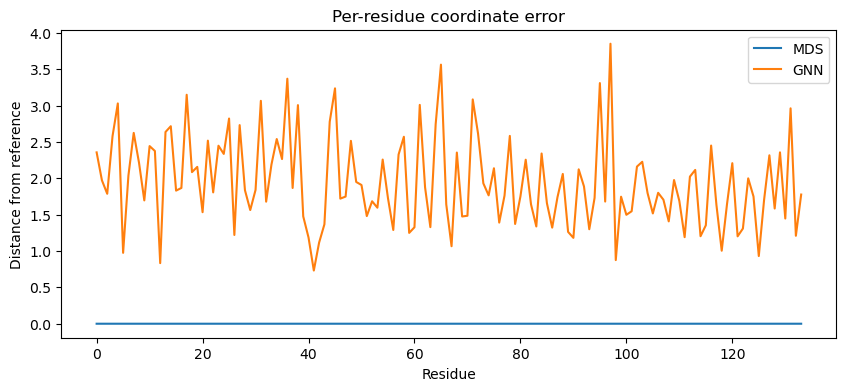

In [20]:
diff_mds = X_mds_aligned - X_ref_centered
diff_gnn = X_pred_aligned - X_ref_centered

dist_mds = np.linalg.norm(diff_mds, axis=1)
dist_gnn = np.linalg.norm(diff_gnn, axis=1)

print("MDS RMSD:", np.sqrt(np.mean(dist_mds**2)))
print("GNN RMSD:", np.sqrt(np.mean(dist_gnn**2)))

print("MDS mean residue error:", np.mean(dist_mds))
print("GNN mean residue error:", np.mean(dist_gnn))

print("MDS max residue error:", np.max(dist_mds))
print("GNN max residue error:", np.max(dist_gnn))

plt.figure(figsize=(10, 4))

plt.plot(dist_mds, label="MDS")
plt.plot(dist_gnn, label="GNN")

plt.xlabel("Residue")
plt.ylabel("Distance from reference")
plt.title("Per-residue coordinate error")
plt.legend()
plt.show()





In [21]:
def pairwise_distances(X):
    diff = X[:, None, :] - X[None, :, :]
    return np.linalg.norm(diff, axis=-1)

D_ref = pairwise_distances(X_ref)
D_mds = pairwise_distances(X_mds)
D_gnn = pairwise_distances(X_pred)

print("MDS distance-map RMSE:",
      np.sqrt(np.mean((D_mds - D_ref) ** 2)))

print("GNN distance-map RMSE:",
      np.sqrt(np.mean((D_gnn - D_ref) ** 2)))

MDS distance-map RMSE: 1.4173992e-06
GNN distance-map RMSE: 1.991321


Number of proteins: 312

MDS:
  Mean RMSD   = 0.002 Å
  Median RMSD = 0.000 Å
  Std RMSD    = 0.040 Å

GNN:
  Mean RMSD   = 2.162 Å
  Median RMSD = 2.189 Å
  Std RMSD    = 0.332 Å

Improvement:
  Improved: 0 / 312 (0.0%)
  Mean RMSD change = 2.159 Å


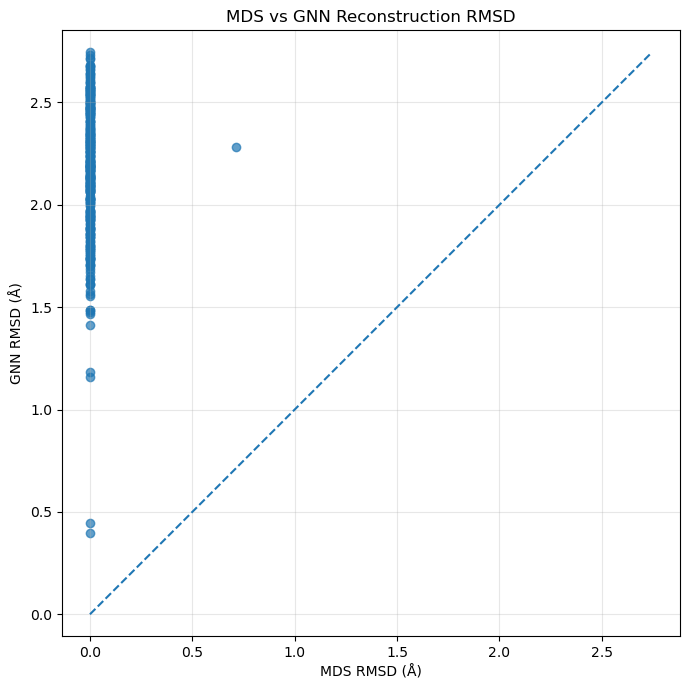

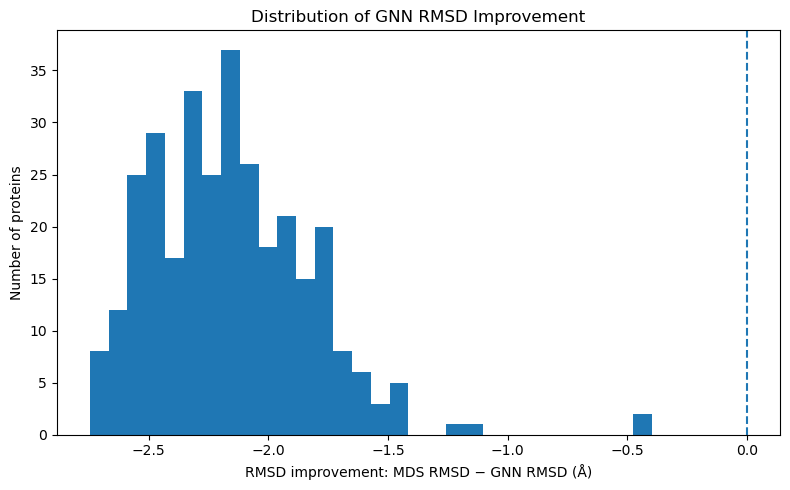

In [22]:


# Load best model
model.load_state_dict(torch.load(save_path))
model.eval()

mds_rmsds = []
gnn_rmsds = []

with torch.no_grad():

    for data in test_loader:

        data = data.to(device)

        # GNN reconstruction
        X_pred = model(
            x0=data.pos,
            node_feat=data.x,
            edge_index=data.edge_index,
            edge_attr=data.edge_attr,
        )

        # Move to CPU
        X_pred = X_pred.cpu().numpy()
        X_mds = data.pos.cpu().numpy()
        X_ref = data.y.cpu().numpy()


        if X_pred.ndim == 2:
            _, _, rmsd_gnn, _, _ = \
                best_alignment_with_scaling_and_mirror(
                    X_pred, X_ref
                )

            _, _, rmsd_mds, _, _ = \
                best_alignment_with_scaling_and_mirror(
                    X_mds, X_ref
                )

            gnn_rmsds.append(rmsd_gnn)
            mds_rmsds.append(rmsd_mds)


mds_rmsds = np.array(mds_rmsds)
gnn_rmsds = np.array(gnn_rmsds)

print(f"Number of proteins: {len(mds_rmsds)}")

print("\nMDS:")
print(f"  Mean RMSD   = {mds_rmsds.mean():.3f} Å")
print(f"  Median RMSD = {np.median(mds_rmsds):.3f} Å")
print(f"  Std RMSD    = {mds_rmsds.std():.3f} Å")

print("\nGNN:")
print(f"  Mean RMSD   = {gnn_rmsds.mean():.3f} Å")
print(f"  Median RMSD = {np.median(gnn_rmsds):.3f} Å")
print(f"  Std RMSD    = {gnn_rmsds.std():.3f} Å")

# How many proteins improved?
improved = gnn_rmsds < mds_rmsds

print("\nImprovement:")
print(f"  Improved: {improved.sum()} / {len(improved)} "
      f"({100 * improved.mean():.1f}%)")

print(f"  Mean RMSD change = "
      f"{np.mean(gnn_rmsds - mds_rmsds):.3f} Å")


plt.figure(figsize=(7, 7))

plt.scatter(
    mds_rmsds,
    gnn_rmsds,
    alpha=0.7
)

# y = x diagonal
min_rmsd = min(mds_rmsds.min(), gnn_rmsds.min())
max_rmsd = max(mds_rmsds.max(), gnn_rmsds.max())

plt.plot(
    [min_rmsd, max_rmsd],
    [min_rmsd, max_rmsd],
    linestyle="--"
)

plt.xlabel("MDS RMSD (Å)")
plt.ylabel("GNN RMSD (Å)")
plt.title("MDS vs GNN Reconstruction RMSD")

plt.axis("equal")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
improvement = mds_rmsds - gnn_rmsds
plt.hist(
    improvement,
    bins=30
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("RMSD improvement: MDS RMSD − GNN RMSD (Å)")
plt.ylabel("Number of proteins")
plt.title("Distribution of GNN RMSD Improvement")

plt.tight_layout()
plt.show()